# Gradient verification for the 1D - non reactive transport (diffusion + advection), permeability inversion from head observations 

The goal here is to verify the correctness of the adjoint state method in HYTEC by comparing the results with the demonstrator's which are considered as correct.

In [1]:
from pathlib import Path
import os
import logging
import copy
import time
from typing import Dict, Generator
import pyrtid
import pyrtid.forward as dmfwd
import pyrtid.inverse as dminv
from pyrtid.utils import indices_to_node_number, node_number_to_indices
import hytecio
import nested_grid_plotter
from nested_grid_plotter import (
    NestedGridPlotter,
    AnimatedPlotter,
    extract_frames_from_embedded_html_animation,
    multi_imshow,
)

# from pyesmda.esmda
from hytecio.core import (
    AdjustableParameter,
    HytecSimulation,
    ParameterFiles,
    Observable,
    ObservationType,
)

from hytecio.job_managers import (
    FrontalHytecRunner,
    JobConfig,
    SlurmHytecRunner,
    QsubHytecRunner,
)
import hytecio.core.model as hymd
from hytecio.utils import (
    StrEnum,
    is_tool,
    get_hytec_version,
    get_mpi_version,
    indices_to_hytec_node_number,
    gen_random_ensemble,
    get_normalized_mean_from_lognormal_params,
    get_normalized_std_from_lognormal_params,
)
from hytecio.plot import plot_observed_vs_simulated
import matplotlib.pyplot as plt
from matplotlib.collections import PolyCollection
from matplotlib.animation import HTMLWriter
from IPython.display import HTML
import numpy as np
import numpy.typing as npt
import pandas as pd
from scipy.ndimage.filters import gaussian_filter
import gstools as gs
from pyrtid.utils import NDArrayFloat, NDArrayInt

gs.config.USE_RUST = True  # Use the rust implementation of gstools

/tmp/ipykernel_23819/1042283484.py:54: DeprecationWarning: Please use `gaussian_filter` from the `scipy.ndimage` namespace, the `scipy.ndimage.filters` namespace is deprecated.
  from scipy.ndimage.filters import gaussian_filter


- Set-up logging level

In [3]:
logger = logging.getLogger()
logger.setLevel(logging.INFO)
logging.info("this is a logging test")

INFO:root:this is a logging test


- Check package/software versions(slurm = clusterfon, qsub = Omines, frontal = local machine)
- Check package/software versions

In [4]:
logging.info(f"hytecio version = {hytecio.__version__}")
logging.info(f"nested_grid_plotter version = {nested_grid_plotter.__version__}")
logging.info(f"pyrtid version = {pyrtid.__version__}")


class RunnerType(StrEnum):
    FRONTAL = "frontal"
    QSUB = "qsub"
    SLURM = "slurm"
    UNKNOWN = "unknown"


hytec_paths = {
    RunnerType.FRONTAL: "hytec",
    RunnerType.QSUB: "/omines/home/public/Programs/HYTEC/hytec-4.7.4",
    RunnerType.SLURM: "/cluster/GEOSCIENCES/home/acollet/hytec/svn/build/bin/Release/hytec",
}

v = ""
runner_type = RunnerType.UNKNOWN
for k, v in hytec_paths.items():
    if is_tool(v):
        runner_type = k
        break

if runner_type == RunnerType.UNKNOWN:
    raise Exception("no valid hytec command found !")

# Path or alias to the hytec binary on your local machine.
hytec_binary_path_or_alias: str = v

logging.info(f"HYTEC version = {get_hytec_version(hytec_binary_path_or_alias)}")

mpi_binary_path_or_alias: str = {
    RunnerType.FRONTAL: "mpiexec",
    RunnerType.QSUB: "mpiexec",
    RunnerType.SLURM: "/cluster/GEOSCIENCES/home/apps/mpich/4.0.2/bin/mpiexec",
}[runner_type]

logging.info(f"mpiexec version = {get_mpi_version(mpi_binary_path_or_alias)}")

dos2unix_binary_path_or_alias = "dos2unix"

INFO:root:hytecio version = 0.1.5
INFO:root:nested_grid_plotter version = 0.1.0
INFO:root:pyrtid version = 0.1.0

INFO:root:HYTEC version = 4.7.4-r1648
INFO:root:mpiexec version = 4.1.1


- Create a directory to store the exported figures

In [5]:
ipynb_path = os.path.dirname(os.path.realpath("__file__"))
fig_save_path = Path(ipynb_path, "exported_figures")
fig_save_path.mkdir(parents=True, exist_ok=True)  # make sure that the directory exists

- Define some configurations for the plots

In [6]:
# Some configs for the plots
new_rc_params = {
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "DejaVu Sans"],
    "font.size": 16,
    "text.usetex": False,
    "savefig.format": "svg",
    "svg.fonttype": "none",  # to store text as text, not as path
    "savefig.facecolor": "w",
    "savefig.edgecolor": "k",
    "savefig.dpi": 300,
    "figure.constrained_layout.use": True,
    "figure.facecolor": "w",
    "axes.facecolor": "w",
}
csfont = {"fontname": "Comic Sans MS"}
hfont = {"fontname": "Helvetica"}
plt.plot()
plt.close()  # required for the plot to update
plt.rcParams.update(new_rc_params)

## Forward problem

- Define a very simple pure diffusion case in 1D.

In [7]:
nx = 100  # number of voxels along the x axis
ny = 1  # number of voxels along the y axis
dx = 0.0001  # voxel dimension along the x axis
dy = 1.0  # voxel dimension along the y axis
nt = 1  # number of time steps -> 5 to be sure that the gradient is correctly computed for the stationary case
dt = 1  # timestep in seconds
# Hydro parameters
k0 = 1e-2  # general permeability

# Values for the x axis ()meters
x_positions_in_meters: NDArrayFloat = np.arange(nx) * dx + dx / 2
storage_coefficient = 1e-4

flow_regime = "stationary"
crank_flow = 1.0

- x_coordinates array for the plots

In [8]:
x_coordinates = (np.arange(nx) + 0.5) * dx

- Three observation wells

In [9]:
observation_locations = [15, 30, 40, 70]

- Create an reference and an initial estimate distribution for the permebility

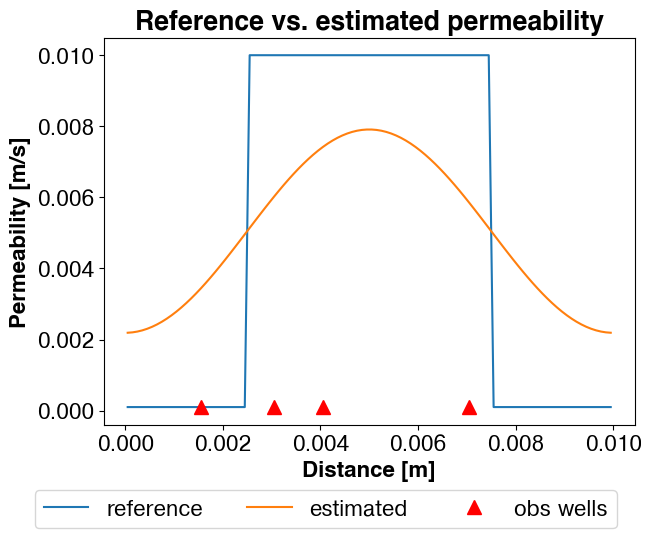

In [10]:
min_val = 1e-4
max_val = 1e-2

perm_reference = np.ones((nx, ny)) * min_val  # m2/s
perm_reference[25:-25, :] = max_val
perm_estimate: NDArrayFloat = gaussian_filter(perm_reference, 20)

plotter = NestedGridPlotter()
ax = plotter.ax_dict["ax1-1"]

ax.set_xlabel("Distance [m]", fontweight="bold")
ax.set_ylabel("Permeability [m/s]", fontweight="bold")
# ax.set_yscale('log')
ax.set_title("Reference vs. estimated permeability", fontweight="bold")
plotter.fig.set_facecolor("w")


ax.plot(x_positions_in_meters, perm_reference, label="reference")
ax.plot(x_positions_in_meters, perm_estimate, label="estimated")

# Add some vertical lines to indicate the well
for well_pos in observation_locations:
    ax.plot(
        (well_pos + 0.5) * dx,
        min_val,
        label="obs wells",
        marker="^",
        markersize=10,
        c="r",
        linestyle="none",
    )

plotter.add_fig_legend(ncol=3)

fname = "true_vs_estimated_initial_permeability"
for format in ["png", "pdf"]:
    plotter.fig.savefig(fig_save_path.joinpath(f"{fname}.{format}"), format=format)

### Forward problem in PyRTID (python demonstrator)

In [11]:
# Simulation on 31 days. We use a 4h timestep.
time_params = dmfwd.TimeParameters(nt=nt, dt_init=dt)
geometry = dmfwd.Geometry(nx=nx, ny=ny, dx=dx, dy=dy)
fl_params = dmfwd.FlowParameters(
    permeability=k0,
    regime={
        "stationary": dmfwd.FlowRegime.STATIONARY,
        "transient": dmfwd.FlowRegime.TRANSIENT,
    }[flow_regime],
    storage_coefficient=storage_coefficient,
    crank_nicolson=crank_flow,
)

base_model = dmfwd.ForwardModel(geometry, time_params, fl_params)

- Add boundary conditions and regional recharge

In [12]:
# Boundary conditions
# Left border (x = 0) at 10 m
base_model.add_boundary_conditions(dmfwd.ConstantHead(span=(slice(0, 1), slice(None))))
base_model.fl_model.head[0, :, :] = 10.0
# Right border (x = xmax) at 2 m
base_model.add_boundary_conditions(
    dmfwd.ConstantHead(span=(slice(nx - 1, nx), slice(None)))
)
base_model.fl_model.head[-1, :, :] = 2.0

- Create two models with different permeabilities

In [13]:
# copy the base model
model_reference = copy.deepcopy(base_model)
# update permeability
model_reference.fl_model.permeability = perm_reference
# solve the flow problem
dmfwd.ForwardSolver(model_reference).solve()

# copy the base model
model_estimate = copy.deepcopy(base_model)
# update permeability
model_estimate.fl_model.permeability[:, :] = perm_estimate
# solve the flow problem
dmfwd.ForwardSolver(model_estimate).solve()

### Forward problem definition in HYTEC

- Define a runner

In [14]:
if runner_type == RunnerType.FRONTAL:
    runner = FrontalHytecRunner(
        hytec_binary_path_or_alias=hytec_binary_path_or_alias,
        mpi_binary_path_or_alias=mpi_binary_path_or_alias,
        nb_cpu=4,
        freq_checks_is_simu_over_sec=5,
    )
elif runner_type == RunnerType.SLURM:
    job_config = JobConfig(
        hytec_binary_path_or_alias=hytec_binary_path_or_alias,
        nb_nodes=1,
        ncpus=4,
        queue="geo-cpu",
        mpi_binary_path_or_alias=mpi_binary_path_or_alias,
        dos2unix_binary_path_or_alias=dos2unix_binary_path_or_alias,
    )
    runner = SlurmHytecRunner(
        job_config=job_config,
        freq_checks_is_simu_over_sec=5,
    )
elif runner_type == RunnerType.QSUB:
    job_config = JobConfig(
        hytec_binary_path_or_alias=hytec_binary_path_or_alias,
        nb_nodes=1,
        ncpus=4,
        queue="Omines_cpu",
        mpi_binary_path_or_alias=mpi_binary_path_or_alias,
        dos2unix_binary_path_or_alias=dos2unix_binary_path_or_alias,
    )
    runner = QsubHytecRunner(
        job_config=job_config,
        freq_checks_is_simu_over_sec=5,
    )
else:
    raise Exception("Could not created runner")

- Create an empty simulation in a non existing folder

In [15]:
simu_base = HytecSimulation("simu_base", Path.cwd().joinpath("simu_base"))

- Add a TDB file

In [16]:
simu_base.link_tdb("./../../../../../TDB/chess.tdb")  # This is relative to the htc file

- Define the output format

In [17]:
simu_base.model.add_sub_item(hymd.OutputFormat("vtk"))

- Hydrodynamic model and its parameters definition


In [18]:
hmodel = hymd.HydrodynamicModel(
    hymd.FlowRegime(flow_regime),
    hymd.FlowCrankNicolson(crank_flow),
    hymd.Permeability(k0, units="m/s"),
    hymd.Porosity(1.0, units="m/s"),
    hymd.Head(0.0, "m"),
    hymd.StorageCoefficient(storage_coefficient),
)
simu_base.model.add_sub_item(hmodel)

- Geochemical unit definition

In [19]:
chmodel = hymd.GeochemicalModel(hymd.Report("full"), hymd.Redox("disabled"))
# Define a geochem unit
base_unit = hymd.GeochemicalUnit("chem_base")
species = "T"
# Set concentrations
base_unit.add_sub_item(hymd.Concentration(species, 1.0, units="molal"))
# define tracer
chmodel.add_sub_item(hymd.Define("basis", species))

# exclude
chmodel.add_sub_item(hymd.Exclude(("minerals", "colloids", "gases")))

# Add the units to the geochemical model
chmodel.add_sub_item(base_unit)

# Add to the main model
simu_base.model.add_sub_item(chmodel)

- Geometry definition

In [20]:
gmodel = hymd.GeometryModel(
    hymd.GridRegime("rectangle"), hymd.Domain(f"{nx*dx},{nx} {ny*dy},{ny}")
)
zone_domain = hymd.Zone(
    "domain", hymd.Geometry("domain"), hymd.Geochemistry(base_unit.name)
)
gmodel.add_sub_item(zone_domain)
simu_base.model.add_sub_item(gmodel)

# 1) Add the producer wells
count_prod: int = 0  # to avoid unbounded values in the next loop
for count_prod, ix in enumerate(observation_locations):
    name = f"well_{ix}"
    zone = hymd.Zone(name)
    zone.add_sub_item(
        hymd.Geometry(
            f"rectangle {(ix + 0.5) * dx},{0.5 * dy}, {dx},{dy}",
            units="m",
        )
    )
    zone.add_sub_item(hymd.Geochemistry(base_unit.name))
    simu_base.model.get_sub_model(hymd.GeometryModel).add_sub_item(zone)

- Boundary model definition

In [21]:
flc_left = hymd.FlowCondition("constant-head at 10.0 m")
flc_right = hymd.FlowCondition("constant-head at 2.0 m")
bmodel = hymd.BoundaryModel(
    hymd.Boundary(
        "border_left", hymd.Coordinates(f"0,0, 0,{ny*dy}", units="m"), flc_left
    ),
    hymd.Boundary(
        "border_right",
        hymd.Coordinates(f"{nx*dx},{ny*dy}, {nx*dx},0", units="m"),
        flc_right,
    ),
)
simu_base.model.add_sub_item(bmodel)

- Time discretization

In [22]:
# Note: the courant factor is set very very high because we are in stationary regime
tmodel = hymd.TimeDiscretizationModel(
    hymd.Duration(nt * dt, units="s"),
    hymd.TimeStep(
        hymd.Variable(
            hymd.StartValue(dt, "s"),
            hymd.Maximum(dt, "s"),
            hymd.CourantFactor(1000000.0),
        ),
    ),
)
simu_base.model.add_sub_item(tmodel)

- Sampling definition

In [23]:
# Sampling model
smodel = hymd.SamplingModel(
    hymd.GridSampling(nt),
    hymd.Select("time", units="s"),
    hymd.Select("node-number"),
    hymd.Select("flowrate", units="m/s"),
    hymd.Select("permeability", units="m/s"),
    hymd.Select("head", units="m"),
)
simu_base.model.add_sub_item(smodel)

- Create two models from this base simulation

In [24]:
simu_reference = copy.deepcopy(simu_base)
simu_reference.update_root_and_name(
    new_root="simu_reference", new_name="simu_reference"
)
simu_estimate = copy.deepcopy(simu_base)
simu_estimate.update_root_and_name(new_root="simu_estimate", new_name="simu_estimate")

- Add the diffusion fields to the simulations

In [25]:
index: NDArrayFloat = np.arange(nx)

# True
data_true = pd.DataFrame(
    data={
        "node-number": index,
        # x and y are cell centers
        "x": (index % nx) * dx + dx / 2,
        "permeability": perm_reference.ravel(),
    },  # need to flatten the parameter
    index=index,
)
simu_reference.add_param_file_data(ParameterFiles.HYDRO, data_true)

# Estimated
data_estimated = pd.DataFrame(
    data={
        "node-number": index,
        # x and y are cell centers
        "x": (index % nx) * dx + dx / 2,
        "permeability": perm_estimate.ravel(),
    },  # need to flatten the parameter
    index=index,
)
simu_estimate.add_param_file_data(ParameterFiles.HYDRO, data_estimated)

- Checking the hydro parameters have been correctly set-up

In [26]:
with pd.option_context("display.max_rows", 10):
    print(simu_reference.handlers.hydro.data)

    node-number        x  permeability
0             0  0.00005        0.0001
1             1  0.00015        0.0001
2             2  0.00025        0.0001
3             3  0.00035        0.0001
4             4  0.00045        0.0001
..          ...      ...           ...
95           95  0.00955        0.0001
96           96  0.00965        0.0001
97           97  0.00975        0.0001
98           98  0.00985        0.0001
99           99  0.00995        0.0001

[100 rows x 3 columns]


In [27]:
with pd.option_context("display.max_rows", 10):
    print(simu_estimate.handlers.hydro.data)

    node-number        x  permeability
0             0  0.00005      0.002191
1             1  0.00015      0.002202
2             2  0.00025      0.002225
3             3  0.00035      0.002258
4             4  0.00045      0.002303
..          ...      ...           ...
95           95  0.00955      0.002303
96           96  0.00965      0.002258
97           97  0.00975      0.002225
98           98  0.00985      0.002202
99           99  0.00995      0.002191

[100 rows x 3 columns]


In [28]:
simu_reference.handlers.modify_files.keys()

dict_keys([])

In [29]:
simu_reference.write_input_files()
simu_estimate.write_input_files()
runner.run(simu_reference)
runner.run(simu_estimate)

INFO:root:The job is over ! Elapsed time = 0:00:00.316275
INFO:root:The job is over ! Elapsed time = 0:00:00.338052


True

### Comparison between hytec and the demonstrator for the forward problem

- Reading the results for the reference diffusion simulation

In [30]:
simu_reference.read_hytec_results()
simu_reference.handlers.results.grid_res_columns

['timestep',
 'Zones',
 'time [s]',
 'node-number []',
 'flowrate [m/s]',
 'permeability [m/s]',
 'head [m]',
 'x-distance']

In [31]:
head_reference_hytec = simu_reference.handlers.results.extract_field_from_grid_res(
    field="head [m]", nx=nx
)
perm_reference_hytec = simu_reference.handlers.results.extract_field_from_grid_res(
    field="permeability [m/s]", nx=nx
)
# Getting sample time. The unit is the same than the one defined for the simulation duration in the htc
grid_sample_times = simu_reference.handlers.results.get_sample_times_from_grid_res()

- Reading the results for the estimated diffusion simulation

In [32]:
simu_estimate.read_hytec_results()
simu_estimate.handlers.results.grid_res_columns

['timestep',
 'Zones',
 'time [s]',
 'node-number []',
 'flowrate [m/s]',
 'permeability [m/s]',
 'head [m]',
 'x-distance']

In [33]:
# Get the results on a 3D grid with the last dimension as time step
head_estimate_hytec = simu_estimate.handlers.results.extract_field_from_grid_res(
    field="head [m]", nx=nx
)
perm_estimate_hytec = simu_estimate.handlers.results.extract_field_from_grid_res(
    field="permeability [m/s]", nx=nx
)

- Plot the forward results

In [34]:
model_reference.fl_model.head.shape

(100, 1, 2)

In [35]:
head_reference_hytec.shape

(100, 1, 1, 2)

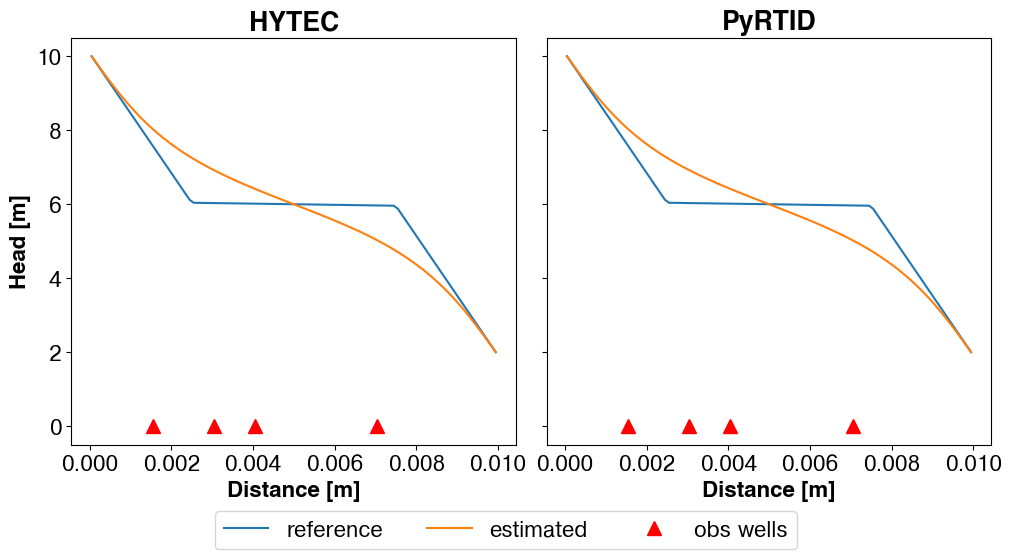

In [36]:
plotter = NestedGridPlotter(
    fig_params={"figsize": (10, 5)},
    subplots_mosaic_params={
        "fig1": {"mosaic": [["ax1-1", "ax1-2"]], "sharex": True, "sharey": True}
    },
)
ax = plotter.ax_dict["ax1-1"]
ax.plot(x_positions_in_meters, head_reference_hytec[:, 0, 0, 0], label="reference")
ax.plot(x_positions_in_meters, head_estimate_hytec[:, 0, 0, 0], label="estimated")
ax.set_xlabel("Distance [m]", fontweight="bold")
ax.set_ylabel("Head [m]", fontweight="bold")
# ax.set_yscale('log')
ax.set_title("HYTEC", fontweight="bold")

ax = plotter.ax_dict["ax1-2"]
ax.plot(
    x_positions_in_meters, model_reference.fl_model.head[:, 0, 0], label="reference"
)
ax.plot(x_positions_in_meters, model_estimate.fl_model.head[:, 0, 0], label="estimated")
ax.set_xlabel("Distance [m]", fontweight="bold")
# ax.set_yscale('log')
ax.set_title("PyRTID", fontweight="bold")


# Add some vertical lines to indicate the well
for ax in plotter.ax_dict.values():
    for well_pos in observation_locations:
        ax.plot(
            (well_pos + 0.5) * dx,
            min_val,
            label="obs wells",
            marker="^",
            markersize=10,
            c="r",
            linestyle="none",
        )

plotter.add_fig_legend(ncol=3)

fname = "true_vs_estimated_initial_permeability"
for format in ["png", "pdf"]:
    plotter.fig.savefig(str(fig_save_path.joinpath(f"{fname}.{format}")), format=format)

## Inversion

- Create a function to add some noise to the observations

In [37]:
noise_std = 0.15  # This is an absolute value
rng = np.random.default_rng(2021)


def get_white_noise(shape: int) -> NDArrayFloat:
    """Return the input with some added white noise.

    Note
    ----
    The parameters are hardcoded to be consistent in the notebook.
    Change the function directly.
    """
    return rng.normal(0.0, noise_std, shape)

- Check the intensity of the noise

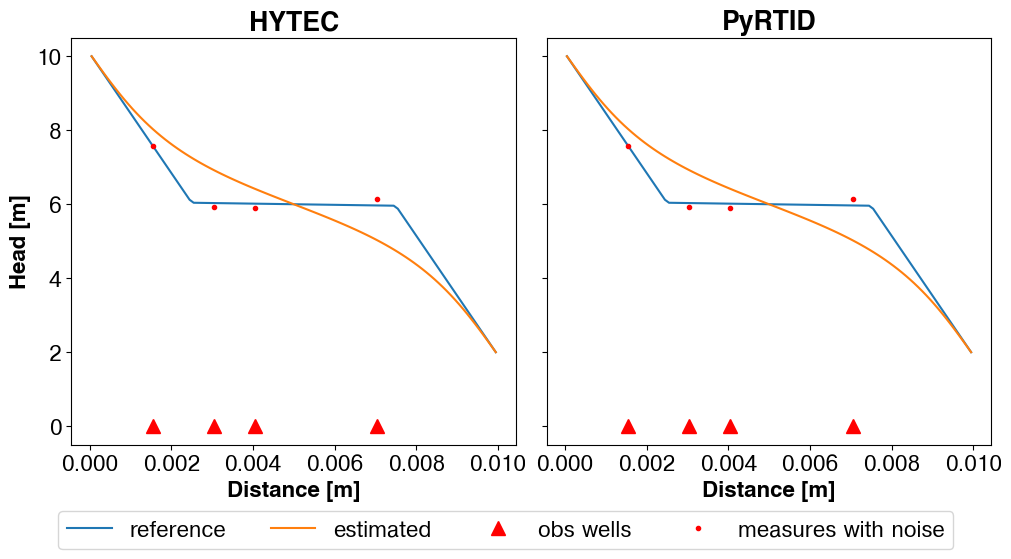

In [38]:
# Generate a white noise
obs_noise: NDArrayFloat = get_white_noise(
    model_reference.fl_model.head[observation_locations, 0, -1].shape[0]
)

# Plot the observations with the white noise
plotter.ax_dict["ax1-1"].plot(
    x_coordinates[observation_locations],
    head_reference_hytec[observation_locations, 0, 0, 0] + obs_noise,
    marker=".",
    c="r",
    linestyle="none",
    label="measures with noise",
)
plotter.ax_dict["ax1-2"].plot(
    x_coordinates[observation_locations],
    model_reference.fl_model.head[observation_locations, 0, 0] + obs_noise,
    marker=".",
    c="r",
    linestyle="none",
    label="measures with noise",
)
plotter.add_fig_legend(ncol=4)
plotter.fig

### Demonstrator


In [39]:
def inverse_function(x: NDArrayFloat) -> NDArrayFloat:
    """Return 1/x."""
    return 1 / x


param = dminv.AdjustableParameter(
    name=dminv.ParameterName.PERMEABILITY,
    lbound=min_val,
    ubound=max_val,
    preconditioner=np.log,
    preconditioner_1st_derivative=inverse_function,
    backconditioner=np.exp,
)

observables = []
for i, node_id in enumerate(observation_locations):
    vals: NDArrayFloat = model_reference.fl_model.head[node_id, 0, :] + obs_noise[i]
    timesteps = np.arange(vals.size)
    observables.append(
        dminv.Observable(
            state_variable=dminv.StateVariable.HEAD,
            location=(slice(node_id, node_id + 1, 1), slice(None)),
            timesteps=timesteps,
            values=vals,
            uncertainties=noise_std,
        )
    )

# Create an executor to keep track of the adjoint model
solver_config = dminv.ScipySolverConfig(
    solver_name="L-BFGS-B",
    solver_options={"maxfun": 20, "maxiter": 20, "ftol": 1e-4, "gtol": 1e-4},
    is_check_gradient=True,
)
model_adjusted = copy.deepcopy(model_estimate)
inverse_model = dminv.InverseModel(param, observables)
executor = dminv.ScipyInversionExecutor(model_adjusted, inverse_model, solver_config)

is_grad_ok = executor.is_adjoint_gradient_correct()
print("Is the gradient correct: ", is_grad_ok)

fl_model.crank_nicolson = 1.0
div
0
div_old
[[ 0.00000000e+00]
 [ 7.10542736e-10]
 [-4.44089210e-10]
 [-4.17443857e-10]
 [ 3.99680289e-10]
 [ 6.21724894e-11]
 [-3.73034936e-10]
 [ 5.41788836e-10]
 [ 1.33226763e-11]
 [ 3.90798505e-10]
 [-2.44249065e-10]
 [-2.57571742e-10]
 [-1.82076576e-10]
 [-1.77635684e-11]
 [ 9.14823772e-10]
 [ 2.88657986e-10]
 [-4.66293670e-10]
 [ 6.30606678e-10]
 [-6.88338275e-10]
 [-7.63833441e-10]
 [ 6.57252031e-10]
 [-3.99680289e-11]
 [-4.44089210e-10]
 [ 1.19015908e-09]
 [-9.19264664e-10]
 [ 7.99360578e-10]
 [-4.61852778e-10]
 [ 7.54951657e-10]
 [-1.38999923e-09]
 [ 8.97060204e-10]
 [-7.06101844e-10]
 [-9.85878046e-10]
 [-4.88498131e-10]
 [ 1.99840144e-10]
 [-1.33226763e-09]
 [ 1.19904087e-10]
 [ 1.25233157e-09]
 [-3.33066907e-10]
 [-7.63833441e-10]
 [ 4.44089210e-10]
 [-4.26325641e-10]
 [-4.44089210e-10]
 [ 4.88498131e-11]
 [ 3.55271368e-10]
 [ 2.01616501e-09]
 [-5.50670620e-10]
 [-6.75015599e-10]
 [ 6.21724894e-10]
 [-6.66133815e-11]
 [ 7.59392549e-10]
 [ 1.3

- Compute the first objective function

In [40]:
executor.scaled_loss_function(param.preconditioner(param.values))

INFO:root:- Running forward model # 1
INFO:root:- Run # 1 over
INFO:root:Loss (obs fit)        = 119.43284518152936
INFO:root:Loss (regularization) = 0.0
INFO:root:Scaling factor        = 0.008372906117074174
INFO:root:Loss (scaled)         = 1.0



1.0

In [41]:
obs = observables[0]

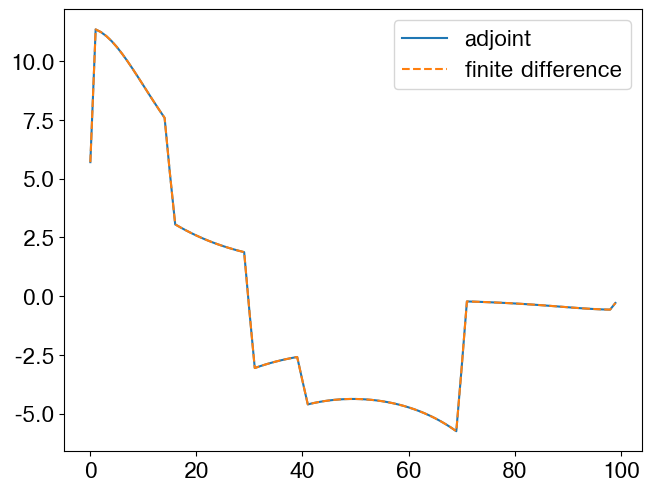

In [42]:
plt.plot(param.archived_adjoint_gradients[0], label="adjoint")
plt.plot(param.archived_fd_gradients[0], label="finite difference", linestyle="--")
plt.legend()

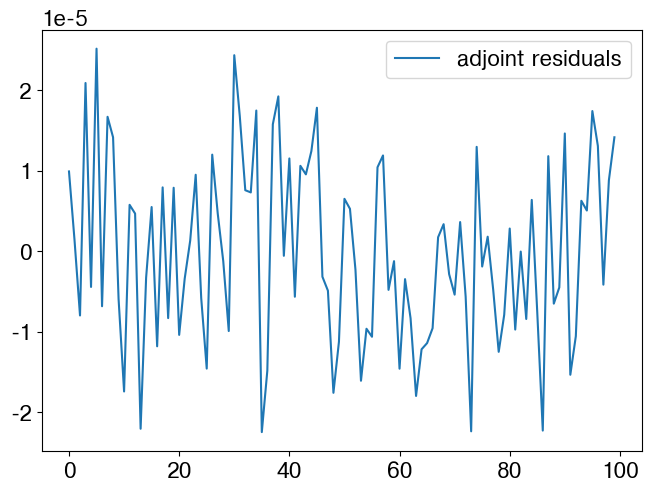

In [43]:
plt.plot(
    param.archived_adjoint_gradients[0] - param.archived_fd_gradients[0],
    label="adjoint residuals",
)
plt.legend()

### HYTEC

In [56]:
# 1) Copy the base simulation
simu_inverse = copy.deepcopy(simu_estimate)
simu_inverse.update_root_and_name(new_root="simu_inverse", new_name="simu_inverse")

# 2) Add the observation wells
for count, ix in enumerate(observation_locations):
    x = (ix + 0.5) * dx
    zone_name = f"well_{ix}"
    # Use the demonstrator values
    vals = np.array(model_reference.fl_model.head[ix, 0, :] + obs_noise[count])

    # Add the observables for the area
    obs = Observable(
        zone_name=zone.name,
        state_variable="head",
        units="m",
        timesteps=grid_sample_times[:],
        time_units="s",
        obs_type=ObservationType.GRID,
        values=vals,
        uncertainties=noise_std,
        node_numbers=[ix] * vals.size,
    )
    simu_inverse.register_observable(
        zone_name, obs, obs_file_path=f"observables/{zone_name}_o.dat"
    )

# 3) Update the htc file with some options
inv_model = hymd.InverseModel(
    hymd.OptimizationStatus("enabled"),
    hymd.OptimizationSolverConfig(
        "lbfgsb", hymd.AdjointStateStatus("enabled"), hymd.FdGradientCheck("initial")
    ),
    hymd.AdjustedParameterConfig(
        "permeability",
        hymd.Lbound(min_val, units="m/s"),
        hymd.Ubound(max_val, units="m/s"),
        hymd.Preconditioner("logarithmic"),
    ),
)
simu_inverse.model.add_sub_item(inv_model)

# number of samples on the adjoint variables
simu_inverse.model.get_sub_model(hymd.SamplingModel).add_sub_item(
    hymd.AdjointGridSampling(nt)
)

# 4)Write the input files
simu_inverse.write_input_files()

runner.run(simu_inverse)

# 7) Read results
simu_inverse.read_hytec_results()  # This fails if not results have been written

INFO:root:The job is over ! Elapsed time = 0:00:01.545713


In [57]:
obs.time_units

's'

- Plot the head field (to be sure it has been correctly reinitialized)

(100, 1, 1, 2)


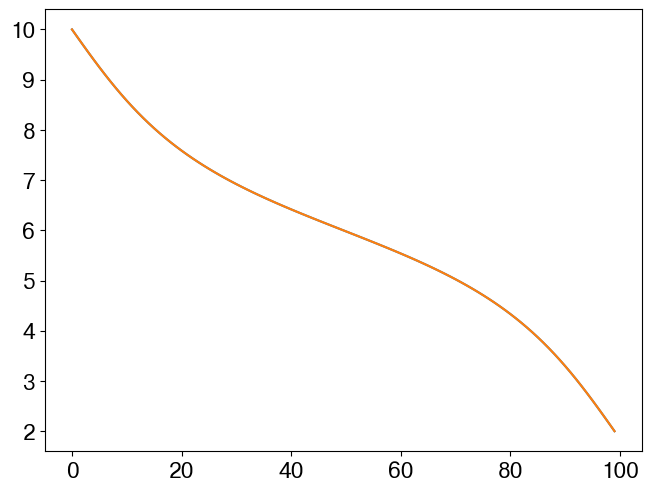

In [58]:
inverse_heads_hytec = simu_inverse.handlers.results.extract_field_from_grid_res(
    field="head [m]", nx=nx
)

print(inverse_heads_hytec.shape)

plt.plot(inverse_heads_hytec[:, 0, 0, 0])
plt.plot(inverse_heads_hytec[:, 0, 0, -1])

- Extract the adjoint variables computed for the first gradient

In [59]:
print(f"columns = {simu_inverse.handlers.results.optim_res.adjoint_var_columns}")

columns = ['timestep', 'Zones', 'node-number []', 'adjoint-variable{head} []', 'x-distance']


In [60]:
adj_head_hytec = simu_inverse.handlers.results.extract_field_from_adj_var_res(
    field="adjoint-variable{head} []", nx=nx
)
adj_head_hytec.shape

(100, 1, 1, 2)

In [61]:
executor.scaled_loss_function(np.log(param.values))

INFO:root:- Running forward model # 3
INFO:root:- Run # 3 over
INFO:root:Loss (obs fit)        = 119.43284518138694
INFO:root:Loss (regularization) = 0.0
INFO:root:Scaling factor        = 0.008372906117074174
INFO:root:Loss (scaled)         = 0.9999999999988075



0.9999999999988075

### Results comparison

The adjoint concentrations should be quite the same both in shape and intensity.

In [62]:
adj_head_hytec[:, 0, 0, 0]

array([ 0.        ,  1.67699556,  3.34127799,  4.98484511,  6.60036423,
        8.1813654 ,  9.72238992, 11.21903571, 12.66794887, 14.06680354,
       15.41422048, 16.70966024, 17.95330285, 19.14592415, 20.28877632,
       21.38347778, 21.84372045, 22.28456368, 22.70696719, 23.11191596,
       23.50040043, 23.8734012 , 24.23187757, 24.57675931, 24.90894095,
       25.22927829, 25.53858637, 25.8376388 , 26.127168  , 26.40786618,
       26.68038672, 26.22401833, 25.7796721 , 25.34640317, 24.92331946,
       24.50957781, 24.10438015, 23.70696983, 23.31662797, 22.93266995,
       22.55444213, 21.87210706, 21.19800651, 20.53108043, 19.87030315,
       19.2146811 , 18.56324576, 17.91504625, 17.26914711, 16.62462384,
       15.98055845, 15.33603517, 14.69013602, 14.0419365 , 13.39050114,
       12.73487908, 12.07410176, 11.40717566, 10.73307507, 10.05073996,
        9.35907065,  8.65692247,  7.94310006,  7.21635148,  6.47536212,
        5.71874824,  4.94505044,  4.1527268 ,  3.34014595,  2.50

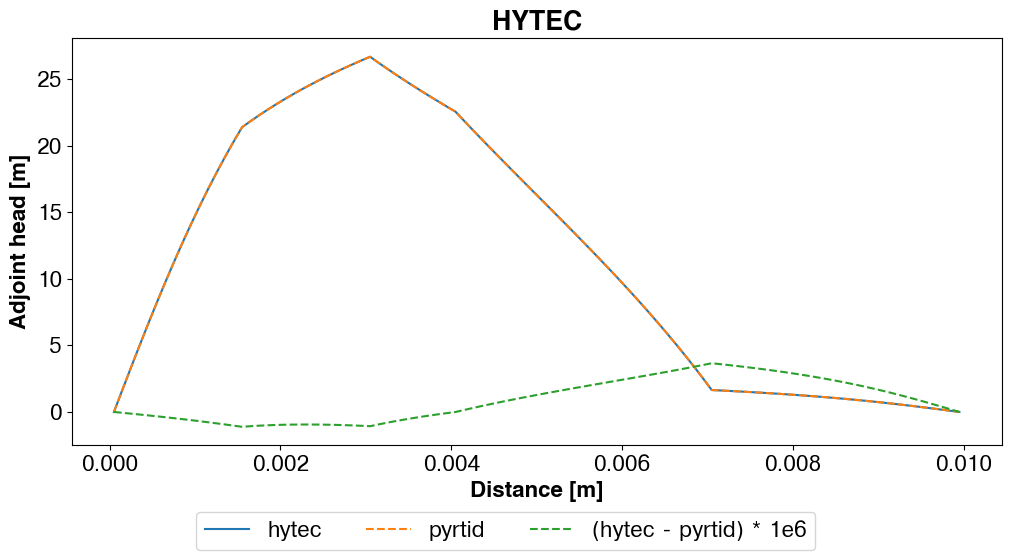

In [63]:
plotter = NestedGridPlotter(
    fig_params={"figsize": (10, 5)},
)
ax = plotter.ax_dict["ax1-1"]
ax.plot(x_positions_in_meters, adj_head_hytec[:, 0, 0, 0], label="hytec")
ax.plot(
    x_positions_in_meters,
    executor.adj_model.a_fl_model.a_head[:, 0, 0],
    label="pyrtid",
    linestyle="--",
)
ax.plot(
    x_positions_in_meters,
    (adj_head_hytec[:, 0, 0, 0] - executor.adj_model.a_fl_model.a_head[:, 0, 0]) * 1e6,
    label="(hytec - pyrtid) * 1e6",
    linestyle="--",
)
ax.set_xlabel("Distance [m]", fontweight="bold")
ax.set_ylabel("Adjoint head [m]", fontweight="bold")
# ax.set_yscale('log')
ax.set_title("HYTEC", fontweight="bold")


# Add some vertical lines to indicate the well

plotter.add_fig_legend(ncol=3)

fname = "true_vs_estimated_initial_permeability"
for format in ["png", "pdf"]:
    plotter.fig.savefig(str(fig_save_path.joinpath(f"{fname}.{format}")), format=format)

- Get the gradients by the adjoint method and finite differences

In [64]:
# Get the HYTEC  Adj gradient
hytec_fd_gradient = simu_inverse.handlers.results.optim_res.fd_gradients[0]
hytec_adjoint_gradient = simu_inverse.handlers.results.optim_res.adjoint_gradients[0]

In [65]:
simu_inverse.handlers.results.optim_res.adjoint_gradients

[    node-number  x-distance     value parameter-name
 0           0.0     0.00005  0.047766   permeability
 1           1.0     0.00015  0.095045   permeability
 2           2.0     0.00025  0.094088   permeability
 3           3.0     0.00035  0.092691   permeability
 4           4.0     0.00045  0.090900   permeability
 ..          ...         ...       ...            ...
 95         95.0     0.00955 -0.004561   permeability
 96         96.0     0.00965 -0.004651   permeability
 97         97.0     0.00975 -0.004721   permeability
 98         98.0     0.00985 -0.004769   permeability
 99         99.0     0.00995 -0.002397   permeability
 
 [100 rows x 4 columns]]

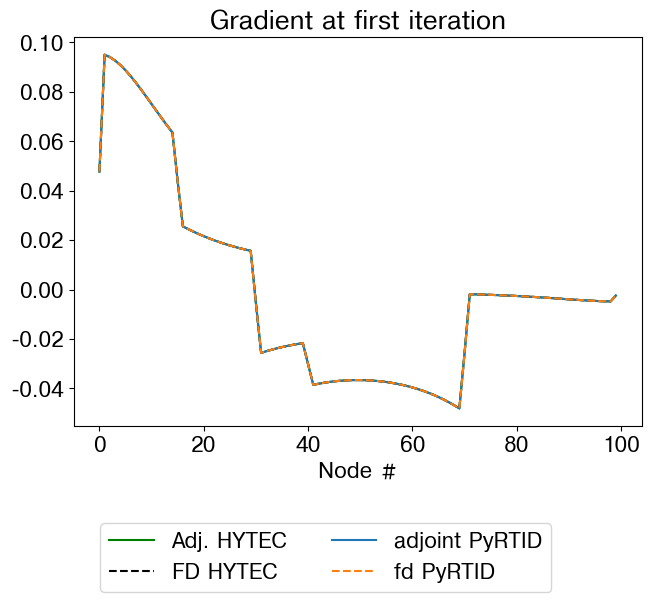

In [66]:
# Here comes the python code
plotter = NestedGridPlotter()

ax = plotter.get_axis("ax1-1")
# hytec
ax.plot(hytec_adjoint_gradient["value"], label="Adj. HYTEC", c="g")
ax.plot(hytec_fd_gradient["value"], label="FD HYTEC", c="k", linestyle="--")
# pyrtid
ax.plot(
    param.archived_adjoint_gradients[0] * executor.inv_model.scaling_factor,
    label="adjoint PyRTID",
    linestyle="-",
)
ax.plot(
    param.archived_fd_gradients[0] * executor.inv_model.scaling_factor,
    label="fd PyRTID",
    linestyle="--",
)


ax.set_title("Gradient at first iteration")
ax.set_xlabel("Node #")
plotter.add_fig_legend(ncol=2, bbox_y_shift=-0.1)

fname = "gradient_dem_vs_hytec_adj_vs_df_1d_diffusion"
for format in ["png", "pdf"]:
    plotter.fig.savefig(fig_save_path.joinpath(f"{fname}.{format}"), format=format)

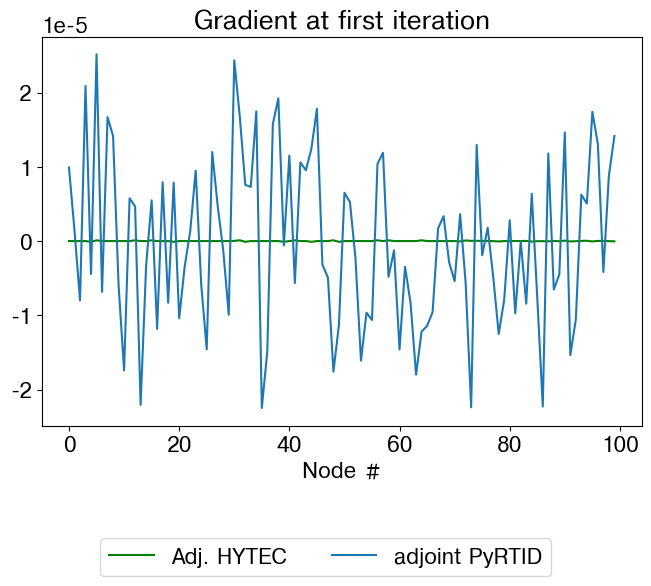

In [67]:
# Here comes the python code
plotter = NestedGridPlotter()

ax = plotter.get_axis("ax1-1")
# hytec
ax.plot(
    hytec_adjoint_gradient["value"] - hytec_fd_gradient["value"],
    label="Adj. HYTEC",
    c="g",
)
# pyrtid
ax.plot(
    param.archived_adjoint_gradients[0] - param.archived_fd_gradients[0],
    label="adjoint PyRTID",
    linestyle="-",
)

ax.set_title("Gradient at first iteration")
ax.set_xlabel("Node #")
plotter.add_fig_legend(ncol=2, bbox_y_shift=-0.1)

fname = "gradient_dem_vs_hytec_adj_vs_df_1d_diffusion"
for format in ["png", "pdf"]:
    plotter.fig.savefig(str(fig_save_path.joinpath(f"{fname}.{format}")), format=format)